# Trading the favorite-longshot bias

The oldest documented anomaly in event contracts is that longshots are
overpriced and favorites underpriced. Recipe 05/02 measured it as a calibration
gap; this one turns it into a position and asks whether it survives the fee
curve. Bucketed hold-to-resolution returns come first, then two engine runs that
take opposite sides of the same bias, then the part that decides it: at which
price levels the edge is larger than the cost of trading there.

## Terms used here

| term                   | meaning |
| ---------------------- | --- |
| favorite-longshot bias | cheap contracts are systematically overpriced and expensive ones underpriced |
| longshot / favorite    | a contract priced far below 0.50, against one priced far above it |
| ask                    | the lowest price a seller will accept, which is what a buyer actually pays |
| hold to resolution     | buy and keep the contract until it settles, rather than trading out |
| calibration gap        | quoted probability minus observed frequency, expressed per contract |
| return on capital      | profit divided by the money committed, which is why price level matters |
| fee curve              | fees scaling with `p*(1-p)`; as a share of capital that is `rate * (1-p)` |
| threshold sweep        | rerunning across a range of cutoffs; a plateau is a finding, a spike is a fitted parameter |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest

db = h5i_db.Database(cu.fresh_db("05_favorite_longshot_bias"), create=True)
FEE_RATE = 0.07
QUANTITY = 20.0

## The panel

One row of `book_deltas` is one price level of one atomic book event. This
recipe needs only the YES ask, which is what a buyer pays, and the resolution.

| column | type | meaning |
|---|---|---|
| `ts_init` | `timestamp[ns]` | recorder arrival; replay order |
| `instrument_id` | `string` | the market |
| `outcome` | `uint16` | 0 = YES, 1 = NO |
| `side` | `string` | `buy` is the bid, `sell` the ask |
| `price` | `float64` | probability on a 0.001 grid |
| `size` | `float64` | contracts at that level |

In [2]:
panel = cu.make_prediction_markets(n_markets=180, steps=32, seed=11)
for name, table in panel.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="panel load")
db.snapshot("panel-v1", tables=list(panel), note="favorite-longshot study")
print(f"{panel['book_deltas'].num_rows:,} book rows, {panel['resolutions'].num_rows} markets")
panel["book_deltas"].to_pandas().head()

25,920 book rows, 180 markets


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,0,snapshot,buy,0.092,89.826,1,False,cookbook-sim
1,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,0,snapshot,sell,0.108,61.859,1,True,cookbook-sim
2,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,1,snapshot,buy,0.879,57.380,2,False,cookbook-sim
3,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,1,snapshot,sell,0.895,100.910,2,True,cookbook-sim
4,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0001,0,snapshot,buy,0.092,121.779,3,False,cookbook-sim


## Hold-to-resolution returns, by price

Fix a decision instant, take the YES ask there, and hold to resolution. The
payoff is 1 if YES won and 0 otherwise, so the return on capital is
`(payoff - ask) / ask`. Bucketing by the ask is the classic presentation: each
bucket is a portfolio of contracts that all looked equally likely.

In [3]:
stamps = sorted({value.as_py() for value in panel["book_deltas"].column("ts_init")})
decision = stamps[8]
decision_ns = int(pd.Timestamp(decision, tz="UTC").value)
quotes = db.sql(
    f"""
    SELECT instrument_id, outcome,
           max(CASE WHEN side = 'buy'  THEN price END) AS bid,
           max(CASE WHEN side = 'sell' THEN price END) AS ask
    FROM h5i('book_deltas', 'panel-v1')
    WHERE ts_init = to_timestamp_nanos({decision_ns})
    GROUP BY instrument_id, outcome
    """
).to_pandas()
truth = cu.market_truth(panel).to_pandas()

yes = quotes[quotes.outcome == 0].merge(truth, on="instrument_id", validate="one_to_one")
yes["payoff"] = yes.yes_won.astype(float)
yes["gross_return"] = (yes.payoff - yes.ask) / yes.ask
yes["fee_per_contract"] = FEE_RATE * yes.ask * (1.0 - yes.ask)
yes["net_return"] = (yes.payoff - yes.ask - yes.fee_per_contract) / yes.ask
print(f"decision instant {decision}, {len(yes)} markets")

EDGES = [0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.88, 1.0]
yes["bucket"] = pd.cut(yes.ask, EDGES)
buckets = (
    yes.groupby("bucket", observed=True)
    .agg(
        n=("ask", "size"),
        mean_ask=("ask", "mean"),
        hit_rate=("payoff", "mean"),
        gross=("gross_return", "mean"),
        net=("net_return", "mean"),
    )
    .assign(edge_pp=lambda f: (f.hit_rate - f.mean_ask) * 100)
)
print(buckets.round(3).to_string())

decision instant 2026-05-01 14:00:00, 180 markets
               n  mean_ask  hit_rate  gross    net  edge_pp
bucket                                                     
(0.0, 0.15]    9     0.120     0.000 -1.000 -1.062  -11.989
(0.15, 0.3]   39     0.230     0.179 -0.233 -0.287   -5.008
(0.3, 0.45]   30     0.383     0.367 -0.032 -0.075   -1.667
(0.45, 0.6]   34     0.529     0.529  0.007 -0.026    0.003
(0.6, 0.75]   32     0.679     0.688  0.011 -0.011    0.834
(0.75, 0.88]  28     0.815     0.857  0.052  0.039    4.221
(0.88, 1.0]    8     0.895     1.000  0.117  0.110   10.487


Buying the cheap buckets loses money and buying the expensive ones makes it,
and the sign flips somewhere in the middle. The `edge_pp` column is the same
calibration gap from recipe 05/02, expressed per contract; `gross` divides it by
the price, which is why a small gap on a 15-cent contract is a large percentage
loss.

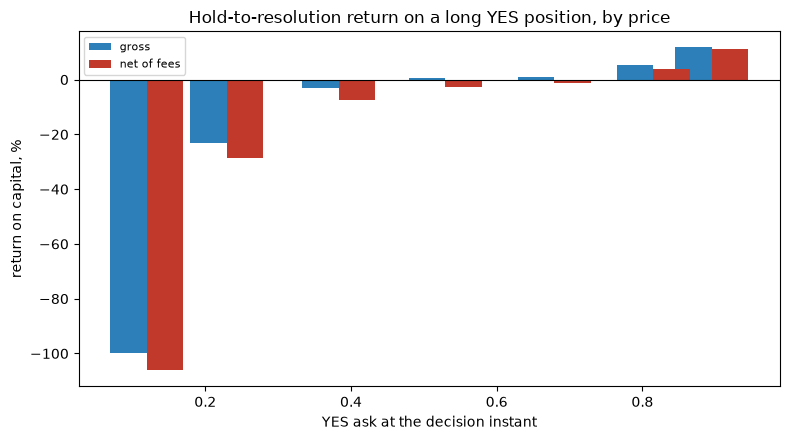

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
centres = buckets.mean_ask
width = 0.05
ax.bar(centres - width / 2, buckets.gross * 100, width=width, label="gross", color="#2c7fb8")
ax.bar(centres + width / 2, buckets.net * 100, width=width, label="net of fees", color="#c0392b")
ax.axhline(0.0, color="black", lw=0.8)
ax.set_title("Hold-to-resolution return on a long YES position, by price")
ax.set_xlabel("YES ask at the decision instant")
ax.set_ylabel("return on capital, %")
ax.legend(fontsize=8)
fig.tight_layout()

## The cost of trading there

The fee is `rate * q * p * (1-p)`, so it is cheapest exactly where the
favorite edge lives. As a *fraction of capital* it is `rate * (1-p)`, which
falls monotonically as the contract gets more expensive. Both effects point the
same way: the favorite side of this bias is the affordable side.

In [5]:
levels = pd.DataFrame({"price": [0.10, 0.25, 0.50, 0.75, 0.90]})
levels["fee_per_contract"] = FEE_RATE * levels.price * (1 - levels.price)
levels["fee_pct_of_capital"] = levels.fee_per_contract / levels.price * 100
print(levels.round(4).to_string(index=False))

 price  fee_per_contract  fee_pct_of_capital
  0.10            0.0063                6.30
  0.25            0.0131                5.25
  0.50            0.0175                3.50
  0.75            0.0131                1.75
  0.90            0.0063                0.70


## Take both sides in the engine

Two runs over the same pin. One buys the favorites, one buys the longshots, and
nothing else differs. Signals are stamped one microsecond after the decision
quote, so each order transacts at the ask it was chosen from.

In [6]:
FAVORITE, LONGSHOT = 0.75, 0.30
submit = decision + dt.timedelta(microseconds=1)


def signals_for(members: pd.DataFrame, tag: str) -> pa.Table:
    rows = [
        {
            "ts": submit,
            "instrument_id": row.instrument_id,
            "outcome": 0,
            "side": "buy",
            "quantity": QUANTITY,
            "tag": tag,
        }
        for row in members.itertuples()
    ]
    return backtest.signal_table(rows).sort_by([("ts", "ascending")])


legs = {
    "favorites": yes[yes.ask >= FAVORITE],
    "longshots": yes[yes.ask <= LONGSHOT],
}
for name, members in legs.items():
    table = signals_for(members, name)
    db.create_table(f"signals_{name}", table.schema, time_column="ts")
    db.append(f"signals_{name}", table)
    print(f"{name:10} {len(members):>3} markets, mean ask {members.ask.mean():.3f}")

favorites   36 markets, mean ask 0.833
longshots   48 markets, mean ask 0.209


In [7]:
def run(name: str, fee_kind: str | None) -> backtest.BacktestResult:
    execution = (
        backtest.ExecutionConfig(fee_kind=fee_kind, fee_rate=FEE_RATE)
        if fee_kind
        else backtest.ExecutionConfig()
    )
    return backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=f"flb-{name}-{fee_kind or 'gross'}",
            data=backtest.DataConfig(signals=f"signals_{name}", snapshot="panel-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
            execution=execution,
            metadata={"study": "favorite-longshot", "leg": name},
        ),
    )


def account(result: backtest.BacktestResult) -> dict[str, float]:
    """Positions are held to resolution, so the result is in settlement_pnl."""
    positions = result.positions.to_pandas()
    fills = result.fills.to_pandas()
    settled = float(positions.settlement_pnl.fillna(0.0).sum())
    fees = float(result.summary()["commissions"])
    capital = float((fills.price * fills.quantity).sum())
    # realized_pnl already nets out commissions, so total = realized + settled.
    # These entries are held to resolution, so realized is exactly -fees and the
    # two agree; a rule that closes positions would make them differ.
    net = float(result.summary()["realized_pnl"]) + settled
    return {
        "fills": len(fills),
        "capital": capital,
        "settled": settled,
        "fees": fees,
        "net": net,
        "net_return_pct": net / capital * 100 if capital else float("nan"),
    }


report = {}
for name in legs:
    for fee_kind in (None, "kalshi"):
        label = f"{name} / {'gross' if fee_kind is None else 'net'}"
        report[label] = account(run(name, fee_kind))
print(pd.DataFrame(report).T.round(2).to_string())

                   fills  capital  settled   fees    net  net_return_pct
favorites / gross   36.0   599.58    40.42   0.00  40.42            6.74
favorites / net     36.0   599.58    40.42   7.11  33.31            5.56
longshots / gross   48.0   200.72   -60.72   0.00 -60.72          -30.25
longshots / net     48.0   200.72   -60.72  11.11 -71.83          -35.79


The favorite leg is positive gross and stays positive after fees. The longshot
leg is negative gross and gets worse. The asymmetry in how much fees take is the
point of the table above: the longshot leg pays a larger fee *relative to the
capital it commits*, so it is the more expensive way to be wrong.

## Where the edge actually is

One threshold is a choice, and choices are where backtests go wrong. Sweeping it
shows whether the finding is a knife-edge or a plateau. Everything here is one
decision instant on one panel, so treat the shape as the result and the level as
noise; recipe 05/05 puts a number on that distinction.

In [8]:
sweep = []
for threshold in np.arange(0.40, 0.92, 0.04):
    members = yes[yes.ask >= threshold]
    if len(members) < 5:
        continue
    sweep.append(
        {
            "threshold": round(float(threshold), 2),
            "markets": len(members),
            "mean_ask": members.ask.mean(),
            "gross_pct": members.gross_return.mean() * 100,
            "net_pct": members.net_return.mean() * 100,
        }
    )
sweep = pd.DataFrame(sweep)
print(sweep.round(2).to_string(index=False))

 threshold  markets  mean_ask  gross_pct  net_pct
      0.40      113      0.66       1.26    -1.13
      0.44      105      0.68       2.17    -0.10
      0.48       97      0.69       1.59    -0.55
      0.52       86      0.72       2.92     0.96
      0.56       80      0.73       1.49    -0.38
      0.60       68      0.76       4.05     2.37
      0.64       61      0.78       5.42     3.86
      0.68       53      0.80       4.04     2.61
      0.72       43      0.82       5.09     3.81
      0.76       32      0.84       7.56     6.46
      0.80       26      0.86       7.92     6.91
      0.84       16      0.88       6.37     5.54
      0.88        8      0.90      11.73    11.00


## Volatility scales with p(1-p)

A practical consequence of the same arithmetic. A contract at 0.05 cannot move
as far as one at 0.50, because it is bounded below at zero. Position sizing that
ignores this over-risks the middle of the book and under-risks the tails.

The scan stops at `expiration_ns`. The panel keeps quoting after the result is
observable, and those snapshots sit at ~1.00 or ~0.00, so including them would
score the resolution jump as a price move. It is the single largest "move" in
the data and it belongs to no volatility estimate.

In [9]:
expiry_ns = int(db.sql("SELECT max(expiration_ns) AS e FROM instruments").to_pandas()["e"][0])
paths = db.sql(
    f"""
    SELECT instrument_id, ts_init,
           (max(CASE WHEN side = 'buy'  THEN price END)
          + max(CASE WHEN side = 'sell' THEN price END)) / 2 AS mid
    FROM h5i('book_deltas', 'panel-v1')
    WHERE outcome = 0 AND ts_init <= to_timestamp_nanos({expiry_ns})
    GROUP BY instrument_id, ts_init
    ORDER BY instrument_id, ts_init
    """
).to_pandas()
paths["step_move"] = paths.groupby("instrument_id").mid.diff()
paths["level"] = paths.groupby("instrument_id").mid.transform("mean").round(1).clip(0.1, 0.9)
vol = (
    paths.dropna(subset=["step_move"])
    .groupby("level")
    .agg(observations=("step_move", "size"), step_vol_bp=("step_move", lambda s: s.std() * 10_000))
    .assign(sqrt_p1mp=lambda f: np.sqrt(f.index * (1 - f.index)))
)
vol["vol_over_sqrt"] = vol.step_vol_bp / vol.sqrt_p1mp
print(vol.round(1).to_string())
print("\nthe last column is roughly flat, which is what p*(1-p) scaling looks like")

       observations  step_vol_bp  sqrt_p1mp  vol_over_sqrt
level                                                     
0.1             372         48.2        0.3          160.8
0.2             744         58.6        0.4          146.5
0.3             651         66.5        0.5          145.1
0.4             620         70.0        0.5          142.8
0.5             682         73.5        0.5          147.1
0.6             775         72.0        0.5          147.0
0.7             682         69.2        0.5          150.9
0.8             620         63.4        0.4          158.6
0.9             434         51.4        0.3          171.3

the last column is roughly flat, which is what p*(1-p) scaling looks like


## Takeaways

- The favorite-longshot bias shows up as a signed calibration gap and survives
  translation into a position: long favorites made money net of fees on this
  panel, long longshots lost it.
- Divide by the price. A three-point gap is a 20% return on a 15-cent contract
  and a 3% return on an 85-cent one, and the fee as a share of capital is
  `rate * (1-p)`, which moves the opposite way.
- Sweep the threshold before believing it. A plateau is a finding; a spike is a
  fitted parameter.
- Price volatility scales with `sqrt(p*(1-p))`. Size positions on that, not on a
  constant.
- h5i-db features doing the work: one named snapshot behind four runs, so the
  gross/net and favorite/longshot comparisons differ only in the field being
  studied, and `bt_fills` supplied the capital actually committed rather than
  the capital intended.

In [10]:
db.close()